# Appendix (Continued)

## A4: Load Libraries

In [ ]:
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

## A5: Load & Visualize the Flowers dataset

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.4HI274_3.0.1/tf_flowers-train.tfrecord*...:   0%|   …

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.


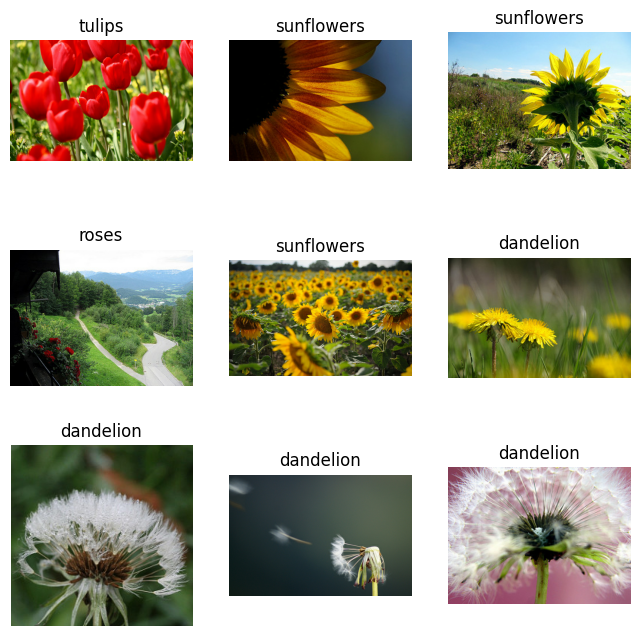

In [ ]:
# Load the dataset from tensor flow data sets (tfds)
# Our dataset is'tf_flowers' -> a built-in dataset in TensorFlow Datasets
# as_supervised=True -> returns data as (image, label) tuples instead of dictionaries
# with_info=True -> also returns metadata (info) about the dataset
dataset, info = tfds.load('tf_flowers', as_supervised=True, with_info=True)

# Extract the training portion of the dataset
# The tf_flowers dataset only has a 'train' split (no separate test set by default) -> we will split later
train_data = dataset['train']

# Get class names from the dataset metadata
# info.features -> describes the structure of the dataset
# 'label' -> target variable (flower type)
# .names -> list of class names (e.g., ['daisy', 'dandelion', ...])
class_names = info.features['label'].names

# Create a figure to display images; figsize=(8,8) sets the width and height of the figure in inches
plt.figure(figsize=(8,8))

# Loop through the first 9 examples in the training dataset to display
# enumerate() -> give both index (i) and the data (image, label)
# .take(9) -> limit the dataset to the first 9 samples
for i, (image, label) in enumerate(train_data.take(9)):
    # Create a subplot grid of 3 rows × 3 columns; i+1 specifies the position (1 through 9)
    plt.subplot(3, 3, i+1)

    # Display the image -> 'image' is a tensor (multi-dimensional array) representing pixel values
    plt.imshow(image)

    # Set the title of the subplot using the label, which is an integer, so we map it to a name
    plt.title(class_names[label])

    # Turn off axis ticks and labels
    plt.axis('off')

# Display
plt.show()

## A6a: Preprocessing
We will simplify the input for the neural network by reducing the dimensionality (image size becomes 32x32, and we scale the pixel values to be between [0, 1] to make a more easily interpretted and controlled range of values for the neural network). This is important because it reduces the "curse of dimensionality" - increasing model performance, computational effeciency, and generalization. Resizing the images also serves a dual purpose; the neural network expects our images to be a certain size when inputted to the network.

In [ ]:
# First preprocess each image
def preprocess(image, label):

    # Resize image to 32x32 pixels -> the original images in tf_flowers have varying sizes, but NNs need a consistent input size
    image = tf.image.resize(image, (32, 32))

    # Ensure pixel values are float32 & scale them
    # tf.cast -> converts from integer (0–255) to float. Then divide by 255.0 to scale values to range [0, 1]
    # Note: this is a simple scaling method, so we can scale on the entire dataset before splitting (as opposed to something like Min-Max normalization)
    image = tf.cast(image, tf.float32) / 255.0

    # Flatten the image into a 1D vector -> 32 * 32 * 3 (RGB channels) = 3072 features
    # [-1] -> flatten everything into one dimension
    image = tf.reshape(image, [-1])

    # Convert TensorFlow tensors (what TensorFlow gives you the data as) into NumPy arrays (we use NumPy operations later)
    return image.numpy(), label.numpy()

# Once preprocessed, we need to build arrays so we can represent each image with its class
# Apply preprocessing to every (image, label) pair in the dataset
# This creates a list of tuples: [(image_array, label), ...]
data = [preprocess(img, lbl) for img, lbl in train_data]

# Extract all image vectors into a single NumPy array
# Each d[0] is a flattened image (length 3072; 32x32x3). Result shape: (number_of_samples, 3072)
X = np.array([d[0] for d in data])

# Extract all labels into a NumPy array
# Each d[1] is a single integer label. Result shape: (number_of_samples,)
y = np.array([d[1] for d in data])

# Print shapes to verify
print("X shape:", X.shape)
print("y shape:", y.shape)

# Split the data into training and test sets -> this is important for evaluation
# Shuffle the dataset before splitting to prevent bias from ordered data (e.g., all one class grouped together)
indices = np.random.permutation(len(X))

# Apply shuffled indices to X and y
X = X[indices]
y = y[indices]

# Define split (80% training, 20% testing)
split = int(0.8 * len(X))

# Split the dataset. The training data will be used for learning
X_train = X[:split]
y_train = y[:split]

# The test data will only be used for evaluation
X_test = X[split:]
y_test = y[split:]

# Print shapes to confirm split
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X shape: (3670, 3072)
y shape: (3670,)
X_train shape: (2936, 3072)
X_test shape: (734, 3072)


We can look at some statistics of our dataset, to get a better idea about its distribution and balance.

In [ ]:
print("--- Dataset Statistics ---")

print(f"Total number of samples: {len(X)}")

num_classes = len(class_names)
print(f"Number of classes: {num_classes}")

# Class Distribution (Counts per category)
print("\nClass Distribution:")
unique_labels, counts = np.unique(y, return_counts=True) # Retreive the unique labels and counts of each category
for label, count in zip(unique_labels, counts): # For each label and count print the label and count
    print(f"  {class_names[label]}: {count} samples")

# Image Dimensions after preprocessing (before flattening)
# Assuming the original resize was to 32x32 pixels with 3 color channels
print(f"\nPreprocessed image dimensions (H, W, C): (32, 32, 3)")
print(f"Flattened feature vector size (32*32*3): {X.shape[1]}")

# Data Types
print(f"\nFeature array (X) data type: {X.dtype}")
print(f"Label array (y) data type: {y.dtype}")


--- Dataset Statistics ---
Total number of samples: 3670
Number of classes: 5

Class Distribution:
  dandelion: 898 samples
  daisy: 633 samples
  tulips: 799 samples
  sunflowers: 699 samples
  roses: 641 samples

Preprocessed image dimensions (H, W, C): (32, 32, 3)
Flattened feature vector size (32*32*3): 3072

Feature array (X) data type: float32
Label array (y) data type: int64


## A6b: Visualize After Preprocessing

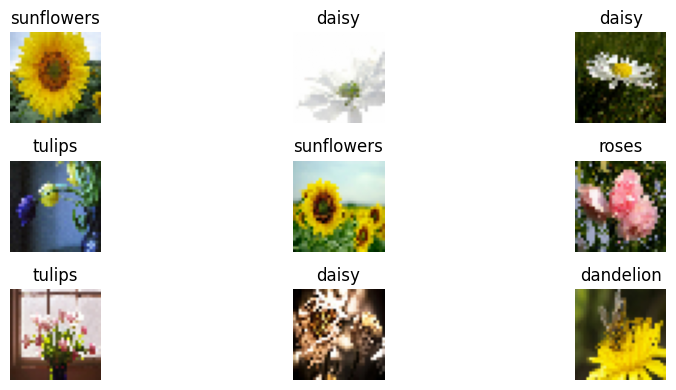

In [ ]:
# Create a figure for plotting
plt.figure(figsize=(10, 4))

# Loop through the first 5 samples
for i in range(9):

    # Get flattened image vector (length 3072)
    img = X[i]

    # Reshape back to image format (32x32x3) -> otherwise the images are flattened vectors
    # This will only change them for viewing after preprocessing, not for the neural network
    img = img.reshape(32, 32, 3)

    # Create subplot (3 row, 3 columns, i + 1 specifies position)
    plt.subplot(3, 3, i + 1)

    # Display the image
    plt.imshow(img)

    # Add class label as title
    plt.title(class_names[y[i]])

    # Hide axis for cleaner output
    plt.axis('off')

# Fix layout spacing
plt.tight_layout()

# Display
plt.show()

## A7: Build NN From Scratch - Initialize Parameters

Initialize parameters:

We will have input 3072 (32x32x3) neurons, hidden layers with 128 and 64 neurons, and output 5 neurons (5 flower classes).

In [ ]:
# Set a random seed for reproducibility -> this way every time the code is run,
# we get the same random numbers (same weights)
np.random.seed(42)

# Layer 1 -> Input Layer to Hidden Layer 1
# Initialize weights for first layer -> shape: (3072, 128)
# 3072 -> number of input features (flattened image: 32*32*3)
# 128 -> number of neurons in first hidden layer
# np.random.randn(...) generates values from a normal distribution (mean=0, std=1)
W1 = np.random.randn(3072, 128) * np.sqrt(2 / 3072)

# Initialize biases for first layer -> shape: (1, 128) -> one bias per neuron
b1 = np.zeros((1, 128)) # Initialized to zeros

# Layer 2 -> Hidden Layer 1 to Hidden Layer 2 -> Shape: (128, 64)
# Initialize weights for second layer
# 128 -> input from previous layer
# 64 -> number of neurons in second hidden layer
# Small random values (0.01 scaling) to prevent large activations early on
W2 = np.random.randn(128, 64) * np.sqrt(2 / 128)

# Initialize biases for second layer. Shape: (1, 64)
b2 = np.zeros((1, 64))

# Layer 3 -> Hidden Layer 2 to Output Layer -> Shape: (64, 5)
# Initialize weights for output layer
# 64 -> input from second hidden layer
# 5 -> number of output classes (flowers: 5 types)
W3 = np.random.randn(64, 5) * np.sqrt(2 / 64)

# Initialize biases for output layer. Shape: (1, 5)
b3 = np.zeros((1, 5))

# Print shapes to verify
print("W1 shape:", W1.shape)
print("b1 shape:", b1.shape)

print("W2 shape:", W2.shape)
print("b2 shape:", b2.shape)

print("W3 shape:", W3.shape)
print("b3 shape:", b3.shape)

W1 shape: (3072, 128)
b1 shape: (1, 128)
W2 shape: (128, 64)
b2 shape: (1, 64)
W3 shape: (64, 5)
b3 shape: (1, 5)


## A8: Forward Pass
Now we implement the forward pass, including the activation functions (ReLU, and Softmax) and the forward propagation through each of the layers. The implemented relu and softmax functions are simply called when we need to perform the respective activation function. The forward function simply implements the chain of nested equations we perform and stores the values of Z and A (the inputs and activations at each level) in a variable to be used for the backward pass later on.

In [ ]:
# ReLU Activation Function
def relu(Z):
    # Apply element-wise ReLU
    # For each value in Z:
    #   if value > 0 -> keep it
    #   if value <= 0 -> replace with 0
    # np.maximum compares each element with 0
    return np.maximum(0, Z)


# Softmax Activation Function
def softmax(Z):
    # Subtract the maximum value in each row for numerical stability
    # axis=1 -> operate across columns (per sample)
    # keepdims=True -> keeps shape compatible for broadcasting
    # This prevents overflow when applying exponential
    expZ = np.exp(Z - np.max(Z, axis=1, keepdims=True))

    # Compute softmax probabilities
    # Divide each exponential by the sum of exponentials in that row
    # Result: each row sums to 1 (valid probability distribution)
    return expZ / np.sum(expZ, axis=1, keepdims=True)


# Forward Pass
def forward(X):

    # Layer 1 -> Input to Hidden Layer 1
    # Linear transformation:
    # Z1 = XW1 + b1
    # X shape:  (batch_size, 3072)
    # W1 shape: (3072, 128)
    # Result:   (batch_size, 128)
    Z1 = X @ W1 + b1

    # Apply ReLU activation: converts linear output into non-linear representation
    # Shape remains (batch_size, 128)
    A1 = relu(Z1)

    # Layer 2 -> Hidden Layer 1 to Hidden Layer 2
    # Linear transformation:
    # Z2 = A1W2 + b2
    # A1 shape: (batch_size, 128)
    # W2 shape: (128, 64)
    # Result:   (batch_size, 64)
    Z2 = A1 @ W2 + b2

    # Apply ReLU activation again. Adds non-linearity so model can learn complex patterns
    A2 = relu(Z2)

    # Layer 3 -> Hidden Layer 2 to Output Layer
    # Linear transformation:
    # Z3 = A2W3 + b3
    # A2 shape: (batch_size, 64)
    # W3 shape: (64, 5)
    # Result:   (batch_size, 5)
    Z3 = A2 @ W3 + b3

    # Apply softmax activation. Converts raw scores (logits) into probabilities
    # Each row will sum to 1
    A3 = softmax(Z3)

    # Store intermediate values for later use (backpropagation). These will be needed to compute gradients
    cache = (Z1, A1, Z2, A2, Z3, A3)

    # A3 -> final predictions (probabilities)
    # cache -> saved values for training (backprop)
    return A3, cache

## A9: Loss - Cross Entropy
The compute_loss function uses categorical cross entropy, which is adapted from negative log likelihood. We take the negative log likelihoods of the correct classes to predict the loss.

In [ ]:
def compute_loss(A3, y):

    # Get number of samples (m = number of training examples)
    m = y.shape[0] # y is shape: (m,)

    # Compute the negative log likelihood for each sample
    # A3 is the model's predicted probabilities (after softmax) from the final layer
    # Shape: (m, num_classes)
    #
    # A3[range(m), y] does:
    #   - For each example i, select the probability that model assigned to the correct class
    #   - range(m) = [0, 1]
    #
    # Example:
    # A3 = [[0.1, 0.7, 0.2], -> sample 0
    #       [0.8, 0.1, 0.1]] -> sample 1
    # y  = [1, 0] -> sample 0 correct class is 1, sample 1 correct class is 0
    #
    # A3[range(2), y] -> [0.7, 0.8] -> find the probability that the model assigned the correct class
    #
    # A3[0, 1] -> row 0, col 1 of A3 -> 0.7. The model assigned a 0.7 probability that sample 0 was class 1
    # A3[1, 0] -> row 1, col 0 of A3 -> 0.8. The model assigned a 0.8 probability that sample 1 was class 0
    #
    # Then:
    # -np.log(...) converts them into loss values
    # High probability -> low loss
    # Low probability -> high loss
    log_likelihood = -np.log(A3[range(m), y])

    # Compute average loss across all samples
    # np.sum(...) adds up all individual losses
    # Divide by m -> mean loss
    return np.sum(log_likelihood) / m

## A10: Backpropagation

In [ ]:
# Derivative of ReLU activation function
def relu_derivative(Z):
    # Returns True (1) where Z > 0, else False (0)
    # This represents the derivative of ReLU:
    # ReLU'(Z) = 1 if Z > 0, else 0
    return Z > 0


# Backpropagation
def backward(X, y, cache):

    # Unpack stored values from forward pass
    # These were saved to avoid recomputing them
    Z1, A1, Z2, A2, Z3, A3 = cache

    # Number of training examples
    m = X.shape[0]

    # Layer 3 -> output layer ---
    # Copy A3 so we don't modify original predictions
    # A3 = softmax output (probabilities)
    dZ3 = A3.copy()

    # Subtract 1 from the correct class probabilities
    # This is the gradient of softmax + cross-entropy loss
    # For each example i:
    #   dZ3[i, y[i]] -= 1
    dZ3[range(m), y] -= 1

    # Divide by m to average gradients over all samples
    dZ3 /= m

    # Compute gradient of weights for layer 3
    # A2.T shape: (64, m)
    # dZ3 shape:  (m, 5)
    # Result:     (64, 5)
    dW3 = A2.T @ dZ3

    # Compute gradient of biases for layer 3
    # Sum over all samples (axis=0 -> column-wise)
    # keepdims=True keeps shape as (1, 5)
    db3 = np.sum(dZ3, axis=0, keepdims=True)

    # Layer 2 ---
    # Backpropagate gradient to previous layer
    # W3.T shape: (5, 64)
    # dZ3 shape:  (m, 5)
    # Result:     (m, 64)
    dA2 = dZ3 @ W3.T

    # Apply derivative of ReLU
    # Only keep gradients where Z2 > 0
    # (ReLU blocks negative values)
    dZ2 = dA2 * (Z2 > 0)

    # Gradient of weights for layer 2
    # A1.T shape: (128, m)
    # dZ2 shape:  (m, 64)
    # Result:     (128, 64)
    dW2 = A1.T @ dZ2

    # Gradient of biases for layer 2
    db2 = np.sum(dZ2, axis=0, keepdims=True)


    # Layer 1 ---
    # Backpropagate gradient further back
    # W2.T shape: (64, 128)
    # dZ2 shape:  (m, 64)
    # Result:     (m, 128)
    dA1 = dZ2 @ W2.T

    # Apply derivative of ReLU again
    dZ1 = dA1 * (Z1 > 0)

    # Gradient of weights for layer 1
    # X.T shape:  (3072, m)
    # dZ1 shape: (m, 128)
    # Result:    (3072, 128)
    dW1 = X.T @ dZ1

    # Gradient of biases for layer 1
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    # Return all gradients - these will be used to update weights during training
    return dW1, db1, dW2, db2, dW3, db3

## A11: Gradient Descent

In [ ]:
# Function to create mini-batches
def get_batches(X, y, batch_size=32):

    # Create a random permutation of indices from 0 to len(X)-1
    # This shuffles the dataset so batches are different each epoch
    # Prevents the model from learning patterns based on data order
    indices = np.random.permutation(len(X))

    # Loop over the dataset in steps of batch_size
    # range(start, stop, step)
    # Example: range(0, 1000, 32)
    for i in range(0, len(X), batch_size):

        # Select a slice of shuffled indices for this batch
        # i:i+batch_size gives a chunk of indices
        batch_idx = indices[i:i+batch_size]

        # Yield (return) the batch of inputs and labels
        # X[batch_idx] -> selects those rows from X
        # y[batch_idx] -> selects corresponding labels
        # 'yield' makes this a generator (memory efficient)
        yield X[batch_idx], y[batch_idx]

# Function to update parameters using gradient descent
def update_params(dW1, db1, dW2, db2, dW3, db3, lr):

    # Declare these variables as global so we can modify them
    # These are the model parameters defined earlier
    global W1, b1, W2, b2, W3, b3

    # Update Layer 1 parameters ---
    # Update weights using gradient descent rule:
    # W = W - learning_rate * gradient
    W1 -= lr * dW1
    # Update biases similarly
    b1 -= lr * db1

    # Update Layer 2 parameters ---
    # Adjust weights for layer 2
    W2 -= lr * dW2
    # Adjust biases for layer 2
    b2 -= lr * db2

    # Update Layer 3 (output layer) parameters ---
    # Update weights for output layer
    W3 -= lr * dW3
    # Update biases for output layer
    b3 -= lr * db3

## A12: Training Loop
Now we will train our model! Every iteration of the outer `for loop` represents an epoch, and every pass of the inner `for loop` represents a pass through a batch. We will calculate the loss every 10 epochs so that we can monitor how our network minimizes the loss during the training process.

In [ ]:
# Loop over the dataset multiple times (epochs)
# One epoch = one full pass through the entire dataset
for epoch in range(50):

    # Iterate over mini-batches of data
    # get_batches() returns small chunks of (X, y)
    for X_batch, y_batch in get_batches(X_train, y_train):

        # Forward pass ---
        # Compute predictions (A3) and store intermediate values (cache)
        A3, cache = forward(X_batch)

        # Backward pass ---
        # Compute gradients of weights and biases using backpropagation
        # These gradients tell us how to adjust parameters
        dW1, db1, dW2, db2, dW3, db3 = backward(X_batch, y_batch, cache)

        # Parameter update ---
        # Update weights and biases using gradient descent
        # lr=0.01 is the learning rate (step size)
        update_params(dW1, db1, dW2, db2, dW3, db3, lr=0.01)

    # Monitor training progress ---
    # Every 10 epochs, print the loss
    if epoch % 10 == 0:

        # Calculate loss over the entire dataset to report
        A3_full, _ = forward(X_train)
        # Compute loss every 10th epoch - for testing purposes, not training
        loss = compute_loss(A3_full, y_train)

        # Print current epoch number and loss value
        # :.4f formats the loss to 4 decimal places
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

# Calculate loss over the entire dataset to report
A3_full, _ = forward(X_train)

# Compute loss for final epoch
loss = compute_loss(A3_full, y_train)

Epoch 0, Loss: 1.3710
Epoch 10, Loss: 1.0038
Epoch 20, Loss: 1.0081
Epoch 30, Loss: 0.6216
Epoch 40, Loss: 0.4514


## A13: Prediction

In [ ]:
# Function to make predictions
def predict(X):

    # Run a forward pass through the network
    # A3 contains the output probabilities for each class
    # Shape: (num_samples, num_classes)
    # We ignore the cache (_) because we don't need it for prediction
    A3, _ = forward(X)

    # Select the index of the highest probability for each sample
    # axis=1 -> operate across columns (classes)
    # For each row, pick the class with the highest probability
    # Result shape: (num_samples,)
    return np.argmax(A3, axis=1)

# Use the model to make predictions on dataset X_test
# preds will contain predicted class labels (integers)
preds = predict(X_test)

# Compute accuracy
# Compare predictions to true labels (y_test). (preds == y_test) creates a boolean array: True where prediction is correct, False otherwise
# np.mean(...) computes fraction of correct predictions: True = 1, False = 0
# So mean = (# correct) / (total samples)
# Multiply by 100 -> convert to percentage
accuracy = np.mean(preds == y_test) * 100

print(f"Accuracy: {round(accuracy, 2)}%")

Accuracy: 44.28%


## A14: Visualize Predictions

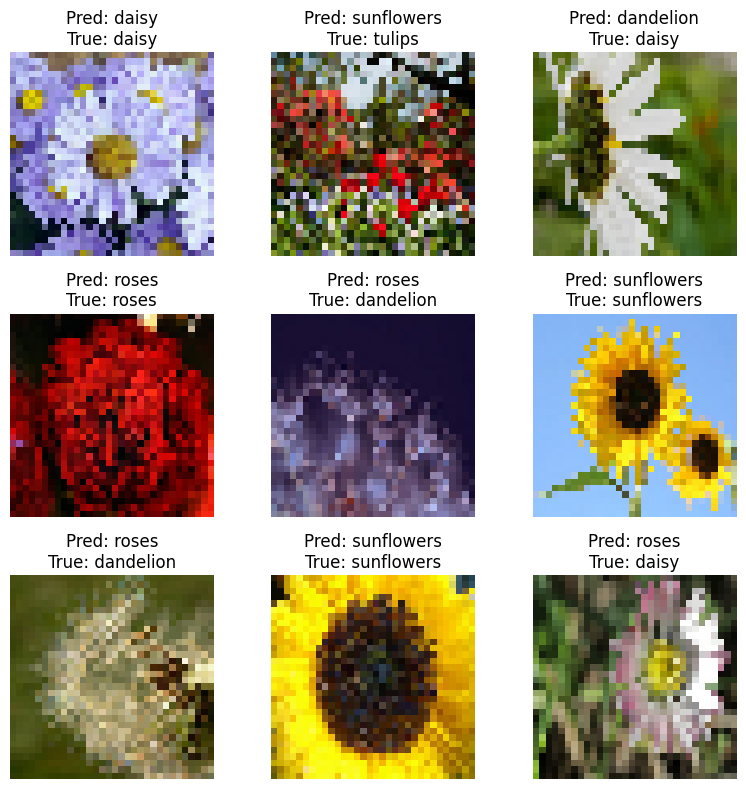

In [ ]:
# Display the first 9 test images in a 3x3 grid using precomputed predictions
plt.figure(figsize=(8, 8))  # Create a square figure

for i in range(9):
    # Take the flattened image and reshape it back to 32x32x3 for display
    img_display = X_test[i].reshape(32, 32, 3)

    # Create subplot (3 rows, 3 columns, position i+1)
    plt.subplot(3, 3, i + 1)

    # Display the image
    plt.imshow(img_display)

    # Display the true predictions vs. ground truth class labels
    plt.title(f"Pred: {class_names[preds[i]]}\nTrue: {class_names[int(y_test[i])]}")

    # Hide axes for cleaner display
    plt.axis('off')

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()

## A15: Confusion Matrix
This part is extra from our neural network, but is useful in examining the performance of our network as we can see the amount of classes predicted correctly, and if there were any classes that were commonly misclassified as another.

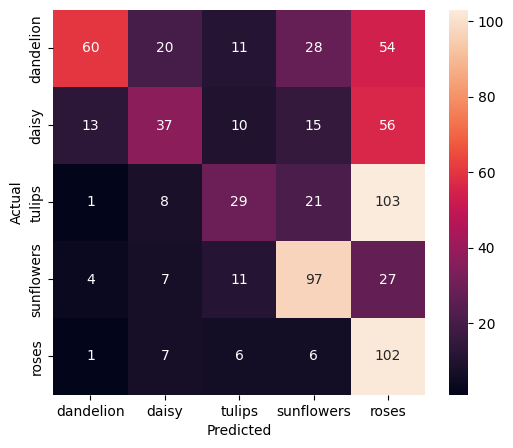

In [ ]:
# Compute confusion matrix
# confusion_matrix compares true labels (y) vs predicted labels (preds)
# Output is a 2D array where rows = actual classes, and columns = predicted classes
cm = confusion_matrix(y_test, preds)

# Create a figure for the heatmap -> figsize=(6,5) controls width and height of the plot
plt.figure(figsize=(6,5))

# Plot the confusion matrix as a heatmap
sns.heatmap(
    cm,                  # The confusion matrix data
    annot=True,          # Show numbers inside each cell
    fmt='d',             # Format numbers as integers (no decimals)

    # Label x-axis (predicted classes) with class names
    xticklabels=class_names,

    # Label y-axis (actual classes) with class names
    yticklabels=class_names
)

# Label the x-axis
# Represents model predictions
plt.xlabel("Predicted")

# Label the y-axis
# Represents true labels (ground truth)
plt.ylabel("Actual")

# Display the plot
plt.show()